# 02 — A global fixed-budget solution needs only polynomially many states.

Let a mask choose exactly $R$ of $N$ channels. There are $\binom NR$ such masks, but we do not need to visit them separately. Prefixes with the same numbers of selected and skipped channels share the same continuation problem.

This notebook derives a global oracle for the **fixed-$R$ importance/latency ratio**, recovers its mask, and compares it with Paper greedy, saturation tiles, and Top-$R$. Its Bellman subproblems are exact; a bounded search locates the optimal ratio to relative accuracy $10^{-6}$. The comparison uses 896 channels, and the size study reaches 4,864. Enumeration appears only in a small correctness check.

All computation is below. There are no input files, project modules, hardware measurements, or generated helper files.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter1d
from itertools import product
from time import perf_counter

## Fix the objective before calling a solution global.

For $v_i\ge0$, let $\mathcal C(M)$ contain the **maximal** contiguous runs of ones in $M$. Define

$$I(M)=\sum_{i=0}^{N-1}v_iM_i,\qquad L(M)=\sum_{C\in\mathcal C(M)}T(|C|),\qquad \boxed{\eta_R^\star=\max_{\|M\|_1=R}\frac{I(M)}{L(M)}}.$$

Here $1\le R\le N$. Adjacent selected intervals form one run and are charged once. We assume the continuous two-line model exactly:

$$T(0)=0,\qquad T(\ell)=\begin{cases}a+b_1\ell,&1\le\ell\le s,\\b_2\ell,&\ell>s,\end{cases}\qquad a=(b_2-b_1)s,\quad 0\le b_1\le b_2,\quad b_2>0.$$

The latency notebook estimated this family from storage data. Here we use **synthetic importance and an analytical cost**, separating selection error from measurement and fitting error. Set $s=32$ **rows**, $b_1=0.25$, and $b_2=1$ in arbitrary cost units. These are not SSD timings, and $s=32$ is not one of the previously measured KiB thresholds.

The earlier `Ratio exact` solved $1\le\|M\|_1\le R$, which can prefer a single short interval and leave budget unused. It is not the oracle for this fixed-cardinality comparison. The old notebook's matched-latency and matched-importance envelope gaps are replaced by a fixed-$R$ ratio gap. This is an explicit change of question, not a claim that the faster DP solves every coverage query or enumerates the entire Pareto frontier.

In [2]:
s, b1, b2 = 32, 0.25, 1.0


def costs(n, s, b1, b2):
    length = np.arange(n + 1)
    T = b2 * length + (b2 - b1) * np.maximum(s - length, 0)
    T[0] = 0
    return T


def runs(mask):
    edges = np.flatnonzero(np.diff(np.r_[False, mask, False]))
    return edges.reshape(-1, 2)


def metrics(v, mask, T):
    spans = runs(mask)
    return v[mask].sum(), T[spans[:, 1] - spans[:, 0]].sum()

## Replace the ratio by a question with an additive answer.

For a proposed ratio $q\ge0$, define

$$F_R(q)=\max_{\|M\|_1=R}\{I(M)-qL(M)\}.$$

Because every feasible latency is positive,

$$\boxed{F_R(q)\ge0\iff q\le\eta_R^\star.}$$

Thus one additive optimization tells us whether $q$ is attainable. This is not a sweep intended to recover every Pareto point: we are locating the zero of the value function for one specified ratio objective.

## The last zero gives an exact recurrence.

Write $Z=N-R$ and $P_j=\sum_{i<j}v_i$. Let $D_{z,r}$ be the largest value of $I-qL$ over prefixes of length $z+r$ containing exactly $z$ zeros and $r$ ones. With no zeros there is only one mask, so

$$D_{0,r}=P_r-qT(r).$$

When $z>0$, place the **last zero** after $t$ selected channels. Before it there are $z-1$ zeros and $t$ ones; after it comes one run of $r-t$ ones. The empty final run $t=r$ is allowed. Therefore

$$\boxed{D_{z,r}=\max_{0\le t\le r}\left[D_{z-1,t}+P_{z+r}-P_{z+t}-qT(r-t)\right].}$$

**Why it is exact.** Every feasible prefix has this unique decomposition. For a fixed $t$, replacing its earlier prefix by the best $D_{z-1,t}$ cannot change the final run or its cost. Conversely, an optimal earlier prefix, one zero, and that final run construct a feasible prefix. Induction on $z$ proves equality, with $F_R(q)=D_{Z,R}$. The separating zero prevents charging two adjacent pieces as separate runs.

This recurrence is valid for any run-length table. There are only $(Z+1)(R+1)$ states, but directly scanning all $t$ still takes $O((Z+1)(R+1)^2)$ time. The two-line form removes that extra factor.

## Two range maxima replace the scan over run lengths.

For a fixed $z$, put

$$A_t=D_{z-1,t}-P_{z+t}+qb_1t,\qquad B_t=D_{z-1,t}-P_{z+t}+qb_2t.$$

Separate a zero-length, short, and long final run:

$$D_{z,r}=\max\left\{\begin{aligned}&D_{z-1,r},\\&P_{z+r}-q(a+b_1r)+\max_{\max(0,r-s)\le t<r} A_t,\\&P_{z+r}-qb_2r+\max_{0\le t<r-s} B_t.\end{aligned}\right.$$

An empty maximum is $-\infty$. The short range is a moving window; the long range grows by one index at a time. Both maxima for an entire row can be computed in $O(R+1)$ time. A moving maximum maintains only undominated indices: each enters and leaves its queue at most once.

Below, `trailing_max(a, w)[j]` means $\max_{\max(0,j-w+1)\le t\le j}a_t$. The SciPy routine implements that linear-time moving maximum; its `origin` places the window behind the current index. `np.maximum.accumulate` is the ordinary prefix maximum. There is no restricted corridor or pruned mask family.

In [3]:
def trailing_max(values, width):
    return maximum_filter1d(values, size=width, origin=(width - 1) // 2,
                            mode="constant", cval=-np.inf)

In [4]:
def bellman(v, R, q, s, b1, b2):
    Z = len(v) - R
    P = np.r_[0., np.cumsum(v)]
    r = np.arange(R + 1)
    D = np.empty((Z + 1, R + 1))
    D[0] = P[:R + 1] - q * costs(R, s, b1, b2)
    width = min(s, R)
    for z in range(1, Z + 1):
        prefix = P[z:z + R + 1]
        previous = D[z - 1] - prefix
        short = np.r_[-np.inf, trailing_max(
            previous[:-1] + q * b1 * r[:-1], width)]
        long = np.full(R + 1, -np.inf)
        long[width + 1:] = np.maximum.accumulate(previous + q * b2 * r)[:R - width]
        D[z] = np.maximum.reduce([
            D[z - 1],
            prefix - q * ((b2 - b1) * s + b1 * r) + short,
            prefix - q * b2 * r + long])
    return D

### Recover a mask, not just its objective value.

At $(z,r)$, choose a maximizing $t$ in the original recurrence. Mark $[z+t,z+r)$ selected and continue at $(z-1,t)$. At $z=0$, the remaining prefix consists entirely of ones. Ties can give different optimal masks.

We keep the value table and rescan one row per backtracking step rather than maintaining another table of predecessors. This also costs $O((Z+1)(R+1))$. Including recovery, one additive solve uses

$$\boxed{O((N-R+1)(R+1))\text{ time and memory}.}$$

The memory bound includes the saved table; it is not a claim of rolling-row memory with free traceback. For $R\simeq N/2$, both bounds are quadratic, not exponential. The extra ones in the formula cover $R=N$ correctly.

In [5]:
def recover(v, R, q, T, D):
    P = np.r_[0., np.cumsum(v)]
    mask = np.zeros(len(v), bool)
    r = R
    for z in range(len(v) - R, 0, -1):
        t = np.arange(r + 1)
        scores = D[z - 1, :r + 1] + P[z + r] - P[z + t] - q * T[r - t]
        start = int(np.argmax(scores))
        mask[z + start:z + r] = True
        r = start
    mask[:r] = True
    return mask

## A bounded ratio search makes the numerical guarantee explicit.

Top-$R$ gives a feasible mask $M_0$ and lower bound $\ell_0=I(M_0)/L(M_0)$. Since $T(\ell)\ge b_2\ell$ and Top-$R$ maximizes importance at fixed cardinality,

$$\ell_0\le\eta_R^\star\le u_0=\frac{\sum_{i\in\mathrm{Top}\text{-}R}v_i}{b_2R}.$$

Test the midpoint $q=(\ell+u)/2$. If $F_R(q)<0$, replace $u$ by $q$. Otherwise recover a feasible mask and replace $\ell$ by its ratio, which is at least $q$. Each step at least halves the bracket. Stop when $u-\ell\le\epsilon\ell_0$; the returned mask then satisfies

$$0\le1-\frac{I(M)/L(M)}{\eta_R^\star}\le\epsilon.$$

For integer $s\ge1$, $L(M_0)\le RT(1)$ and $T(1)/b_2\le s$, so $u_0/\ell_0\le s$. At most $\lceil\log_2(s/\epsilon)\rceil$ additive solves suffice. If all importance is zero, both bounds are zero immediately. Consequently the full ratio solve, **to the stated accuracy**, takes

$$\boxed{O(N\log N+(N-R+1)(R+1)\log(s/\epsilon))\text{ arithmetic operations}.}$$

The first term is the single Top-$R$ sort. At a half budget the quadratic DP term dominates.

We use $\epsilon=10^{-6}$. The Bellman recurrence is exact mathematically; the implementation uses float64, not formal interval arithmetic. We report both numerical bounds rather than calling a fixed number of ratio updates an exact solve. This distinction matters when interpreting very small gaps.

In [6]:
def top_r(v, R):
    mask = np.zeros(len(v), bool)
    mask[np.argsort(-v, kind="stable")[:R]] = True
    return mask

In [7]:
def solve(v, R, s, b1, b2, rtol=1e-6):
    assert 1 <= R <= len(v) and s >= 1 and 0 <= b1 <= b2 and b2 > 0
    assert 0 < rtol < 1
    T = costs(len(v), s, b1, b2)
    mask = top_r(v, R)
    I, L = metrics(v, mask, T)
    lower, upper = I / L, I / (b2 * R)
    tolerance = rtol * lower
    calls = 0
    while upper - lower > tolerance:
        q = (lower + upper) / 2
        D = bellman(v, R, q, s, b1, b2)
        calls += 1
        if D[-1, -1] >= 0:
            mask = recover(v, R, q, T, D)
            I, L = metrics(v, mask, T)
            lower = I / L
        else:
            upper = q
    return mask, lower, upper, calls

## Enumeration is a check of the recurrence, not the main oracle.

On at most nine channels we enumerate all masks independently. A separate column-by-column run counter evaluates their costs. We check every positive row budget, several ratio candidates, and the final bracket. The cases include zero importance, zero short slope, equal slopes, $s=1$, and $s>N$. Comparing values rather than masks allows legitimate ties.

In [8]:
def enumerate_small(v, T):
    masks = np.array(list(product([False, True], repeat=len(v))))
    latency = np.zeros(len(masks))
    length = np.zeros(len(masks), int)
    for column in masks.T:
        latency[~column] += T[length[~column]]
        length = np.where(column, length + 1, 0)
    return masks, masks @ v, latency + T[length]

In [9]:
checks = 0
for n in (1, 5, 9):
    for v in (np.zeros(n), np.random.default_rng(n).uniform(0, 4, n)):
        for boundary in (1, 4, n + 2):
            for short_slope in (0., 0.25, 1.):
                T = costs(n, boundary, short_slope, 1.)
                masks, imp, delay = enumerate_small(v, T)
                for R in range(1, n + 1):
                    allowed = masks.sum(axis=1) == R
                    for q in (0., 0.1, 1., 10.):
                        D = bellman(v, R, q, boundary, short_slope, 1.)
                        mask = recover(v, R, q, T, D)
                        I, L = metrics(v, mask, T)
                        exact = np.max(imp[allowed] - q * delay[allowed])
                        assert mask.sum() == R
                        np.testing.assert_allclose([D[-1, -1], I - q * L], exact, atol=1e-9)
                        checks += 1
                    mask, lower, upper, calls = solve(v, R, boundary, short_slope, 1.)
                    exact = np.max(imp[allowed] / delay[allowed])
                    assert lower - 1e-9 <= exact <= upper + 1e-9
                    np.testing.assert_allclose(metrics(v, mask, T)[0] / metrics(v, mask, T)[1], lower)
                    assert upper - lower <= 1e-6 * lower + 1e-9
pd.Series({"Additive values and recovered masks checked": checks,
           "Largest enumerated channel count": 9})

Additive values and recovered masks checked    1080
Largest enumerated channel count                  9
dtype: int64

## Compare selectors under the same constraint and the same cost.

**Paper greedy** implements the multiscale selection rule: score every interval of lengths $1,\ldots,s$ by $I(C)/T(|C|)$, sort, and accept nonoverlapping intervals until $R$ rows are selected. Length-one candidates make exact filling possible here. This is a dense row-unit baseline, not a reproduction of the paper's GPU implementation or its tuned candidate grid.

In [10]:
def paper(v, R, T, s):
    P = np.r_[0., np.cumsum(v)]
    candidates = []
    for length in range(1, min(s, len(v), R) + 1):
        for start in range(len(v) - length + 1):
            candidates.append(((P[start + length] - P[start]) / T[length], start, length))
    candidates.sort(key=lambda row: -row[0])
    mask = np.zeros(len(v), bool)
    remaining = R
    for _, start, length in candidates:
        if length <= remaining and not mask[start:start + length].any():
            mask[start:start + length] = True
            remaining -= length
            if remaining == 0:
                break
    return mask

**Saturation tiles** restrict the geometry instead. For each grid offset $0$ and $\lfloor s/2\rfloor$, choose the $\lfloor R/s\rfloor$ highest-importance full tiles, then the best disjoint interval of length $R\bmod s$. Choose the better resulting mask by its merged-run ratio. For $R<s$, choose the best length-$R$ interval. Top-$R$ simply selects the largest individual values. All four selectors return exactly $R$ rows; all are evaluated by `metrics`, which merges adjacent pieces before charging latency.

In [11]:
def tiles(v, R, T, s):
    P = np.r_[0., np.cumsum(v)]
    if R < s:
        start = np.argmax(P[R:] - P[:-R])
        mask = np.zeros(len(v), bool)
        mask[start:start + R] = True
        return mask
    choices = []
    k, remaining = divmod(R, s)
    for offset in (0, s // 2):
        starts = np.arange(offset, len(v) - s + 1, s)
        if len(starts) < k:
            continue
        weights = P[starts + s] - P[starts]
        mask = np.zeros(len(v), bool)
        for start in starts[np.argsort(-weights, kind="stable")[:k]]:
            mask[start:start + s] = True
        if remaining:
            occupied = np.r_[0, np.cumsum(mask)]
            valid = occupied[remaining:] == occupied[:-remaining]
            if not valid.any():
                continue
            scores = np.where(valid, P[remaining:] - P[:-remaining], -np.inf)
            start = np.argmax(scores)
            mask[start:start + remaining] = True
        I, L = metrics(v, mask, T)
        choices.append((I / L, mask))
    return max(choices, key=lambda row: row[0])[1]

## Spatial arrangement changes which heuristic is competitive.

Use 896 channels and $R/N\in\{1/4,1/2,3/4\}$. In each of three seeded nonuniform inputs, draw a lognormal multiset. The scattered arrangement retains its random order; the clustered arrangement assigns its sorted values to the ranks of a periodic sine wave. The multisets are identical within each pair. Normalize mean importance to one and also include a flat input, giving **seven vectors and 21 fixed-budget problems**.

These are controlled synthetic inputs, not extracted model activations. They test the consequence of spatial arrangement, not a claim about the frequency of that arrangement in a VLM.

In [12]:
def importance(n, kind, seed, s):
    if kind == "flat":
        return np.ones(n)
    values = np.random.default_rng(seed).lognormal(0, 1, n)
    if kind == "clustered":
        order = np.argsort(np.sin(2 * np.pi * np.arange(n) / (4 * s)), kind="stable")
        values[order] = np.sort(values)
    return values / values.mean()

For a heuristic ratio $u_M=I(M)/L(M)$, the true gap is $g(M)=100(1-u_M/\eta_R^\star)$. The numerical bracket yields

$$\max(0,100(1-u_M/\ell))\le g(M)\le\max(0,100(1-u_M/u)).$$

We show the upper end of this interval, rather than silently treating the oracle's finite tolerance as zero. Its uncertainty is at most $0.0001$ percentage points in exact arithmetic. Importance, latency, and run count are retained separately; a larger ratio does not mean larger importance.

In [13]:
N = 896
T = costs(N, s, b1, b2)
inputs = [("flat", 0)] + [(kind, seed) for kind in ("scattered", "clustered") for seed in range(3)]
records, examples = [], {}
for kind, seed in inputs:
    v = importance(N, kind, seed, s)
    for R in (N // 4, N // 2, 3 * N // 4):
        oracle, lower, upper, calls = solve(v, R, s, b1, b2)
        methods = {"Global DP": oracle, "Paper greedy": paper(v, R, T, s),
                   "Saturation tiles": tiles(v, R, T, s), "Top-R": top_r(v, R)}
        for name, mask in methods.items():
            I, L = metrics(v, mask, T)
            assert mask.sum() == R and I / L <= upper + 1e-9
            records.append(dict(kind=kind, seed=seed, R=R, method=name,
                importance=I, latency=L, retained_pct=100 * I / v.sum(), chunks=len(runs(mask)),
                gap_lower_pct=max(0, 100 * (1 - I / L / lower)),
                gap_upper_pct=max(0, 100 * (1 - I / L / upper))))
        if seed == 0 and R == N // 2:
            examples[kind] = methods
frame = pd.DataFrame(records)
summary = frame.groupby(["kind", "method"]).gap_upper_pct.agg(["median", "max"])
summary.rename(columns={"median": "Median gap upper (%)", "max": "Maximum gap upper (%)"}).round(3)

Median gap upper (%)  Maximum gap upper (%)
kind      method                                                       
clustered Global DP                        0.000                  0.000
          Paper greedy                     1.630                  5.958
          Saturation tiles                 0.027                  1.432
          Top-R                            0.331                  1.531
flat      Global DP                        0.000                  0.000
          Paper greedy                     0.000                  0.000
          Saturation tiles                 0.000                  0.000
          Top-R                            0.000                  0.000
scattered Global DP                        0.000                  0.000
          Paper greedy                     5.653                  9.695
          Saturation tiles                 7.631                 13.848
          Top-R                           89.537                 90.898

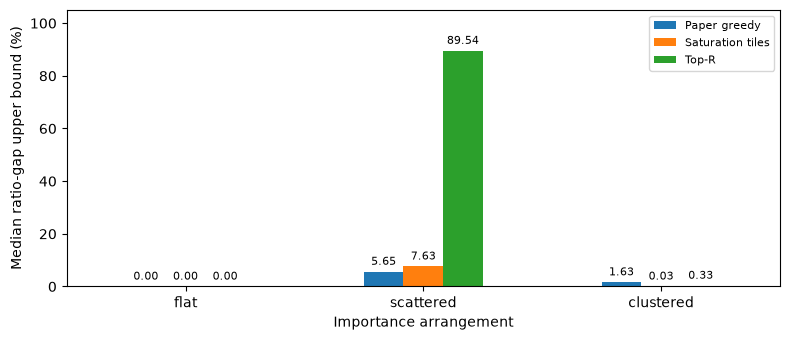

In [14]:
gaps = frame[frame.method != "Global DP"].groupby(["kind", "method"]).gap_upper_pct.median().unstack()
gaps = gaps.reindex(["flat", "scattered", "clustered"])
ax = gaps.plot.bar(figsize=(8, 3.5), rot=0)
for bars in ax.containers:
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)
plt.ylim(0, 105)
plt.xlabel("Importance arrangement")
plt.ylabel("Median ratio-gap upper bound (%)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Figure 1.** The flat input has no preference among sufficiently long runs: all four methods attain the ratio optimum. With scattered importance, Paper's median ratio gap is **5.653%**, versus **7.631%** for saturation tiles and **89.537%** for Top-R. With the same values clustered spatially, the medians are **1.630%**, **0.027%**, and **0.331%**, respectively.

There is no uniformly best heuristic here. Tiles benefit from coherent regions, while their fixed boundaries can miss valuable scattered rows. The exact fixed-budget problem, not a favorable example, defines the comparison standard. These conclusions concern the declared synthetic cost and inputs.

In [15]:
example = frame[(frame.kind == "scattered") & (frame.seed == 0) & (frame.R == N // 2)]
example.set_index("method")[["importance", "latency", "chunks", "gap_upper_pct"]].round(3)

,importance,latency,chunks,gap_upper_pct
method,,,,
Global DP,576.677,448.0,12,0.000
Paper greedy,573.226,472.0,15,5.653
Saturation tiles,533.086,448.0,10,7.559
Top-R,747.003,5536.0,226,89.517


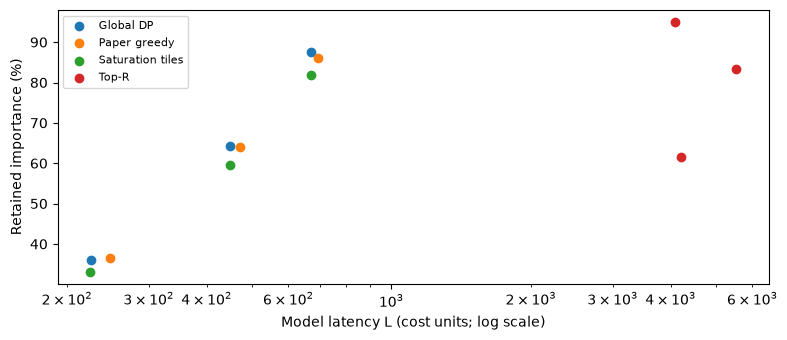

In [16]:
points = frame[(frame.kind == "scattered") & (frame.seed == 0)]
plt.figure(figsize=(8, 3.5))
for name, group in points.groupby("method", sort=False):
    plt.scatter(group.latency, group.retained_pct, label=name)
plt.xscale("log")
plt.xlabel("Model latency L (cost units; log scale)")
plt.ylabel("Retained importance (%)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Figure 2.** Each point is a feasible mask at one of the three row budgets. The horizontal scale is logarithmic. The DP points are fixed-R ratio optima to tolerance, **not a complete Pareto frontier**. At R = 448 in the first scattered input, Top-R retains **747.003** importance, more than the DP's **576.677**, but costs **5,536** instead of **448**. It opens **226** runs rather than **12**. Saturation tiles also cost **448**, but retain only **533.086** importance. Paper retains **573.226** at cost **472**. The ratio trades these quantities rather than maximizing each independently.

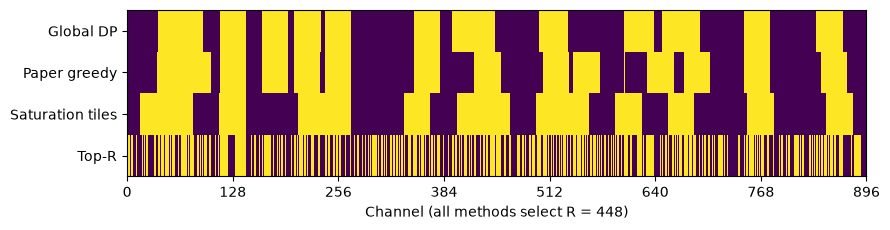

In [17]:
methods = examples["scattered"]
plt.figure(figsize=(9, 2.4))
plt.imshow(np.array(list(methods.values())), aspect="auto", interpolation="nearest")
plt.yticks(range(len(methods)), list(methods))
plt.xticks(np.arange(0, N + 1, 128))
plt.xlabel("Channel (all methods select R = 448)")
plt.tight_layout()
plt.show()

**Figure 3.** Bright cells are selected. The same input and budget produce different geometries. The model can also be written

$$L(M)=b_2R+(b_2-b_1)\sum_{C\in\mathcal C(M)}(s-|C|)_+.$$

Only short runs incur the extra penalty. In the illustrated input, both DP and saturation tiles attain the lower cost $b_2R$, but DP retains more importance. This does **not** prove that every optimum uses only long runs: the solved scattered case with seed 0 and $R=224$ instead has cost **224.75**, with run lengths **54, 31, 32, 43, 32, 32**. The 31-row run contributes the extra 0.75 cost. A valuable short run can be worth its penalty. The DP does not impose the tile heuristic's geometry.

## The same solver reaches thousands of channels.

Measure complete `solve` calls at $R=N/2$, with the same model and seeded scattered-input rule. Each reported time is the median of three local CPU runs, including bracket search and mask recovery. No compilation or storage I/O is involved. The table reports the number of Bellman calls and the float64 value-table size; this is not total process memory.

In [18]:
scaling = []
for n in (128, 256, 512, 896, 2048, 4864):
    v = importance(n, "scattered", 0, s)
    R = n // 2
    seconds = []
    for repeat in range(3):
        start = perf_counter()
        mask, lower, upper, calls = solve(v, R, s, b1, b2)
        seconds.append(perf_counter() - start)
    assert mask.sum() == R and upper - lower <= 1e-6 * lower + 1e-9
    assert calls <= np.ceil(np.log2(s / 1e-6))
    scaling.append(dict(N=n, R=R, states=(R + 1) * (n - R + 1), calls=calls,
        seconds=np.median(seconds), table_MiB=8 * (R + 1) * (n - R + 1) / 2**20,
        ratio_lower=lower, ratio_upper=upper))
timing = pd.DataFrame(scaling)
timing.round(6)

,N,R,states,calls,seconds,table_MiB,ratio_lower,ratio_upper
0,128,64,4225,23,0.029364,0.032234,1.272563,1.272564
1,256,128,16641,23,0.062699,0.126961,1.268713,1.268713
2,512,256,66049,23,0.144652,0.503914,1.294723,1.294723
3,896,448,201601,22,0.274598,1.538094,1.287227,1.287227
4,2048,1024,1050625,23,0.853240,8.015633,1.298713,1.298713
5,4864,2432,5919489,21,2.870262,45.162117,1.293959,1.293959


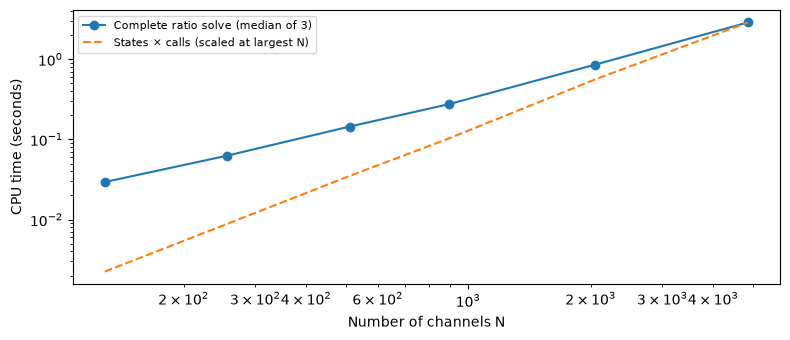

In [19]:
plt.figure(figsize=(8, 3.5))
plt.loglog(timing.N, timing.seconds, "o-", label="Complete ratio solve (median of 3)")
work = timing.states * timing.calls
reference = timing.seconds.iloc[-1] * work / work.iloc[-1]
plt.loglog(timing.N, reference, "--", label="States × calls (scaled at largest N)")
plt.xlabel("Number of channels N")
plt.ylabel("CPU time (seconds)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Figure 4.** The dashed curve is the proved state-work count rescaled for comparison, not an independent timing prediction. At N = 4,864 and R = 2,432, the Bellman table has **5,919,489** entries and occupies **45.162 MiB**. The saved run uses **21** Bellman calls, below the worst-case bound of **25** at this $s$ and tolerance. The timing table contains the measured wall times for this host; a different CPU may give different times. The polynomial count follows from the recurrence, not from fitting this plot.

### What is established

The oracle searches the whole fixed-cardinality mask space under the specified two-line cost. Its additive steps are exact, and its ratio bracket quantifies the remaining numerical optimization error. The recovered importance and latency belong to an actual mask, not an interpolated point.

This is an offline model-based reference, not a claim of a two-millisecond online selector or a measured SSD speedup. Replacing the analytical cost by an arbitrary lookup table preserves the last-zero recurrence but not its two-range acceleration. A coverage optimum or an entire Pareto frontier is a different problem; it is not supplied merely by sweeping a scalar price.

The old small-mask illustration is now a verification step. State compression, rather than a limit on channel count, supplies the global comparison.

### Mathematical context

The fixed-budget objective follows [idea.md](../../../preliminary_research/idea.md). The selected/skipped-count formulation extends the full-state oracle in [Experiment 28](../../../experiments/28_exact_corridor/README.md); unlike a fixed count of Dinkelbach updates, the bracket above bounds ratio error and iteration count. [Experiment 07](../../../experiments/07_exact_n4864/README.md) used a different, affine-cost coverage DP. SciPy documents the moving maximum's linear-time bound in [maximum_filter1d](https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.maximum_filter1d.html). These links are context, not runtime inputs.